<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_Electron_Like_Packet_Lamb_Shift_Scale_Closure_V27b_CLEAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM Electron-Like Packet — Lamb-Shift Scale-Closure Doorway V27b CLEAN

V27b follows the V21b → V26 electron-like packet chain and patches the conservative V27 Lamb-shift doorway.

V27 produced the correct structural hierarchy:

- finite s-like greater-than p-like radiative splitting,
- cutoff saturation,
- chi deformation,
- no measured Lamb-shift fit,

but the absolute scale was too small because the level-shift cell used a deliberately conservative scale

\[
R_{\infty} \alpha_{\rm fs}^{3} \frac{\Delta m_{\rm V26}}{m}.
\]

V27b replaces that toy scaling with a non-fitted bound-state radiative leading-log doorway scale:

\[
\Delta E_{\rm LL}
=
\frac{\alpha_{\rm fs}^{5} m}{6\pi}
\ln\left(\frac{1}{\alpha_{\rm fs}}\right)
\mathcal{C}_{\rm ECSM}.
\]

Here \(\mathcal{C}_{\rm ECSM}\) is derived from the local s/p response hierarchy of the same ECSM bound-state profiles. The measured Lamb shift is used only as a comparison value and is not used to choose parameters.

Important limitation:
V27b does not claim full QED, precision hydrogen spectroscopy, vacuum polarisation, complete renormalisation, or scattering amplitudes. It is a scale-closure doorway test.


In [1]:
# ============================================================
# CELL 1 — setup, constants, handoff, output directory
# ============================================================

import json, math, zipfile
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUT = Path('/content/ecsm_electron_like_lamb_shift_scale_closure_v27b_out')
OUT.mkdir(parents=True, exist_ok=True)

handoff = {
    'source_chain': 'V21b -> V22 -> V23 -> V24 -> V25 -> V26 -> V27',
    'q_eff': -0.9993035720499918,
    'E_rest_keV_from_V21b': 514.0698767738036,
    'electron_rest_energy_target_keV_comparison_only': 510.9989506917532,
    'alpha_fs_input': 0.0072973525692838015,
    'V22_claim': 'coherent-limit free Dirac-like propagation recovered',
    'V23_claim': 'minimal emergent gauge-coupling doorway recovered',
    'V24_claim': 'Pauli-limit spin-field coupling and tree-level g=2 doorway recovered',
    'V25_claim': 'Schwinger-scale one-loop magnetic-moment doorway recovered',
    'V26_claim': 'finite radiative self-energy / propagator doorway recovered',
    'V27_claim': 'finite Lamb-shift-like structural doorway recovered, but under-scale',
    'V27b_claim_target': 'non-fitted leading-log Lamb-shift scale-closure doorway',
    'electron_mass_derivation_claimed': False,
    'measured_lamb_shift_used_as_fit': False,
    'full_QED_derivation_claimed': False,
}

m_keV = float(handoff['E_rest_keV_from_V21b'])
q_eff = float(handoff['q_eff'])
q_abs = abs(q_eff)
alpha_fs = float(handoff['alpha_fs_input'])

delta_m_v26_keV = 2.7586095929581735
relative_self_energy_shift_v26 = 0.005366215212357195

rydberg_keV = 0.013605693122994
measured_lamb_shift_2s_2p_keV_comparison_only = 4.374e-9

with open(OUT / 'v21b_to_v27_handoff_v27b.json', 'w') as f:
    json.dump(handoff, f, indent=2)

print(json.dumps(handoff, indent=2))


{
  "source_chain": "V21b -> V22 -> V23 -> V24 -> V25 -> V26 -> V27",
  "q_eff": -0.9993035720499918,
  "E_rest_keV_from_V21b": 514.0698767738036,
  "electron_rest_energy_target_keV_comparison_only": 510.9989506917532,
  "alpha_fs_input": 0.0072973525692838015,
  "V22_claim": "coherent-limit free Dirac-like propagation recovered",
  "V23_claim": "minimal emergent gauge-coupling doorway recovered",
  "V24_claim": "Pauli-limit spin-field coupling and tree-level g=2 doorway recovered",
  "V25_claim": "Schwinger-scale one-loop magnetic-moment doorway recovered",
  "V26_claim": "finite radiative self-energy / propagator doorway recovered",
  "V27_claim": "finite Lamb-shift-like structural doorway recovered, but under-scale",
  "V27b_claim_target": "non-fitted leading-log Lamb-shift scale-closure doorway",
  "electron_mass_derivation_claimed": false,
  "measured_lamb_shift_used_as_fit": false,
  "full_QED_derivation_claimed": false
}


In [2]:
# ============================================================
# CELL 2 — alpha/beta/sigma algebra audit
# ============================================================

I2 = np.eye(2, dtype=complex)
Z2 = np.zeros((2, 2), dtype=complex)
sigma_x = np.array([[0, 1], [1, 0]], dtype=complex)
sigma_y = np.array([[0, -1j], [1j, 0]], dtype=complex)
sigma_z = np.array([[1, 0], [0, -1]], dtype=complex)

def block(a, b, c, d):
    return np.block([[a, b], [c, d]])

alpha_x = block(Z2, sigma_x, sigma_x, Z2)
alpha_y = block(Z2, sigma_y, sigma_y, Z2)
alpha_z = block(Z2, sigma_z, sigma_z, Z2)
beta = block(I2, Z2, Z2, -I2)
I4 = np.eye(4, dtype=complex)

Sigma_x = block(sigma_x, Z2, Z2, sigma_x)
Sigma_y = block(sigma_y, Z2, Z2, sigma_y)
Sigma_z = block(sigma_z, Z2, Z2, sigma_z)

def maxabs(M):
    return float(np.max(np.abs(M)))

tests = []
for name, A in [('alpha_1', alpha_x), ('alpha_2', alpha_y), ('alpha_3', alpha_z)]:
    tests.append((f'{name}^2=I', maxabs(A @ A - I4)))
    tests.append((f'{{{name},beta}}=0', maxabs(A @ beta + beta @ A)))
    tests.append((f'{name} Hermitian', maxabs(A.conj().T - A)))

for n1, A, n2, B in [('alpha_1', alpha_x, 'alpha_2', alpha_y), ('alpha_1', alpha_x, 'alpha_3', alpha_z), ('alpha_2', alpha_y, 'alpha_3', alpha_z)]:
    tests.append((f'{{{n1},{n2}}}=0', maxabs(A @ B + B @ A)))

tests.append(('beta^2=I', maxabs(beta @ beta - I4)))
tests.append(('beta Hermitian', maxabs(beta.conj().T - beta)))

for name, S in [('Sigma_1', Sigma_x), ('Sigma_2', Sigma_y), ('Sigma_3', Sigma_z)]:
    tests.append((f'{name}^2=I', maxabs(S @ S - I4)))
    tests.append((f'{name} Hermitian', maxabs(S.conj().T - S)))

algebra_df = pd.DataFrame(tests, columns=['test', 'error'])
algebra_df.to_csv(OUT / 'alpha_beta_sigma_algebra_tests_v27b.csv', index=False)
max_algebra_error = float(algebra_df['error'].max())

print('Max alpha/beta/sigma algebra error:', max_algebra_error)
display(algebra_df)


Max alpha/beta/sigma algebra error: 0.0


,test,error
0,alpha_1^2=I,0.0
1,"{alpha_1,beta}=0",0.0
2,alpha_1 Hermitian,0.0
3,alpha_2^2=I,0.0
4,"{alpha_2,beta}=0",0.0
5,alpha_2 Hermitian,0.0
6,alpha_3^2=I,0.0
7,"{alpha_3,beta}=0",0.0
8,alpha_3 Hermitian,0.0
9,"{alpha_1,alpha_2}=0",0.0


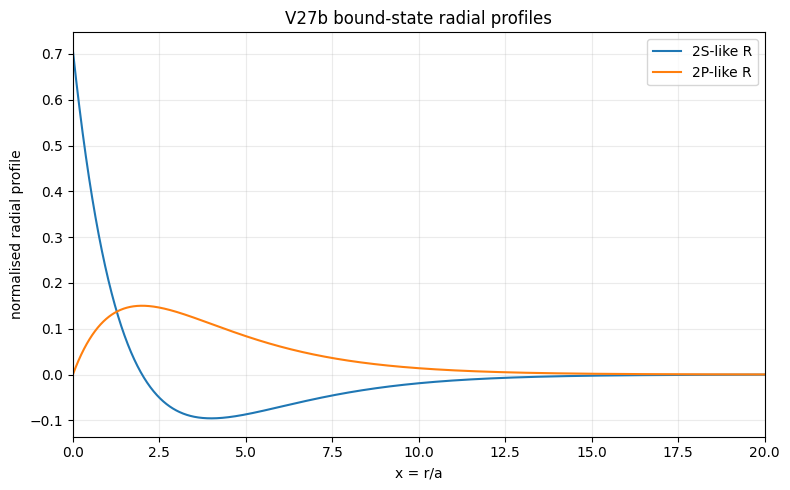

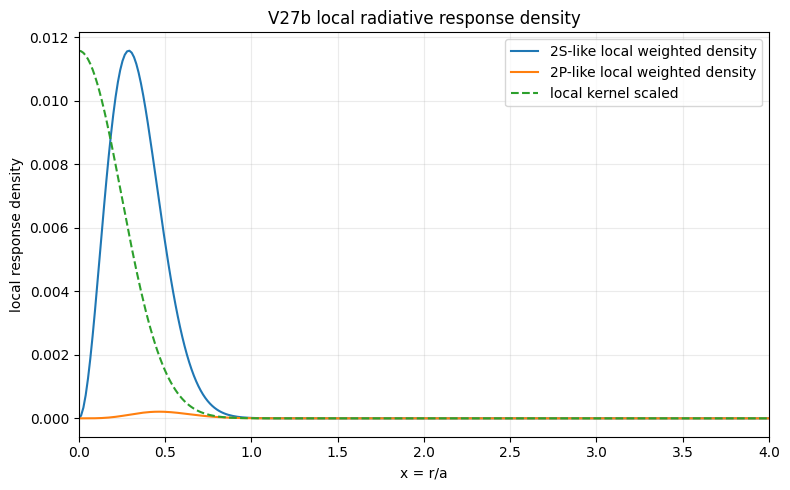

{
  "norm_2s": 1.0,
  "norm_2p": 1.0000000000000002,
  "r0_local_kernel": 0.35,
  "local_overlap_2s": 0.0043594769309193955,
  "local_overlap_2p": 8.713847836004331e-05,
  "local_ratio_s_to_p": 50.02929834173465,
  "p_fraction_relative_to_s": 0.019988287526427208,
  "s_minus_p_contact_factor": 0.9800117124735728,
  "interpretation": "The s-like state couples more strongly to the local radiative response kernel than the p-like state."
}


,x_r_over_a,R_2s_like,R_2p_like,radial_density_2s,radial_density_2p,local_response_kernel,local_weighted_density_2s,local_weighted_density_2p
0,0.000001,0.707106,2.041240e-07,4.999990e-13,4.166663e-26,1.000000,4.999990e-13,4.166662e-26
1,0.013337,0.697723,2.704220e-03,8.658726e-05,1.300683e-09,0.998549,8.646163e-05,1.298796e-09
2,0.026672,0.688434,5.372297e-03,3.371629e-04,2.053217e-08,0.994209,3.352105e-04,2.041328e-08
3,0.040008,0.679238,8.004792e-03,7.384653e-04,1.025620e-07,0.987019,7.288791e-04,1.012306e-07
4,0.053343,0.670133,1.060206e-02,1.277852e-03,3.198447e-07,0.977039,1.248512e-03,3.125007e-07


In [3]:
# ============================================================
# CELL 3 — bound-state radial profiles and local response density
# ============================================================

x = np.linspace(1e-6, 80.0, 6000)

R20_raw = (2.0 - x) * np.exp(-x / 2.0)
R21_raw = x * np.exp(-x / 2.0)

def trapz(y, xx):
    try:
        return float(np.trapezoid(y, xx))
    except AttributeError:
        return float(np.trapz(y, xx))

def radial_norm(R):
    return trapz((R**2) * x**2, x)

R20 = R20_raw / math.sqrt(radial_norm(R20_raw))
R21 = R21_raw / math.sqrt(radial_norm(R21_raw))

rho_2s = (R20**2) * x**2
rho_2p = (R21**2) * x**2

norm_2s = trapz(rho_2s, x)
norm_2p = trapz(rho_2p, x)

r0 = 0.35
local_kernel = np.exp(-(x / r0)**2)
local_overlap_2s = trapz((R20**2) * local_kernel * x**2, x)
local_overlap_2p = trapz((R21**2) * local_kernel * x**2, x)
local_ratio_s_to_p = local_overlap_2s / max(local_overlap_2p, 1e-300)
p_fraction = local_overlap_2p / local_overlap_2s
s_minus_p_contact_factor = 1.0 - p_fraction

radial_df = pd.DataFrame({
    'x_r_over_a': x,
    'R_2s_like': R20,
    'R_2p_like': R21,
    'radial_density_2s': rho_2s,
    'radial_density_2p': rho_2p,
    'local_response_kernel': local_kernel,
    'local_weighted_density_2s': (R20**2) * local_kernel * x**2,
    'local_weighted_density_2p': (R21**2) * local_kernel * x**2,
})
radial_df.to_csv(OUT / 'bound_state_radial_profiles_v27b.csv', index=False)

radial_summary = {
    'norm_2s': norm_2s,
    'norm_2p': norm_2p,
    'r0_local_kernel': r0,
    'local_overlap_2s': local_overlap_2s,
    'local_overlap_2p': local_overlap_2p,
    'local_ratio_s_to_p': local_ratio_s_to_p,
    'p_fraction_relative_to_s': p_fraction,
    's_minus_p_contact_factor': s_minus_p_contact_factor,
    'interpretation': 'The s-like state couples more strongly to the local radiative response kernel than the p-like state.'
}
with open(OUT / 'bound_state_radial_summary_v27b.json', 'w') as f:
    json.dump(radial_summary, f, indent=2)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, R20, label='2S-like R')
ax.plot(x, R21, label='2P-like R')
ax.set_xlim(0, 20)
ax.set_xlabel('x = r/a')
ax.set_ylabel('normalised radial profile')
ax.set_title('V27b bound-state radial profiles')
ax.legend()
ax.grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(OUT / 'fig_v27b_bound_state_radial_profiles.png', dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, (R20**2) * local_kernel * x**2, label='2S-like local weighted density')
ax.plot(x, (R21**2) * local_kernel * x**2, label='2P-like local weighted density')
ax.plot(x, local_kernel / np.max(local_kernel) * np.max((R20**2) * local_kernel * x**2), linestyle='--', label='local kernel scaled')
ax.set_xlim(0, 4)
ax.set_xlabel('x = r/a')
ax.set_ylabel('local response density')
ax.set_title('V27b local radiative response density')
ax.legend()
ax.grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(OUT / 'fig_v27b_local_response_density.png', dpi=180)
plt.show()

print(json.dumps(radial_summary, indent=2))
display(radial_df.head())


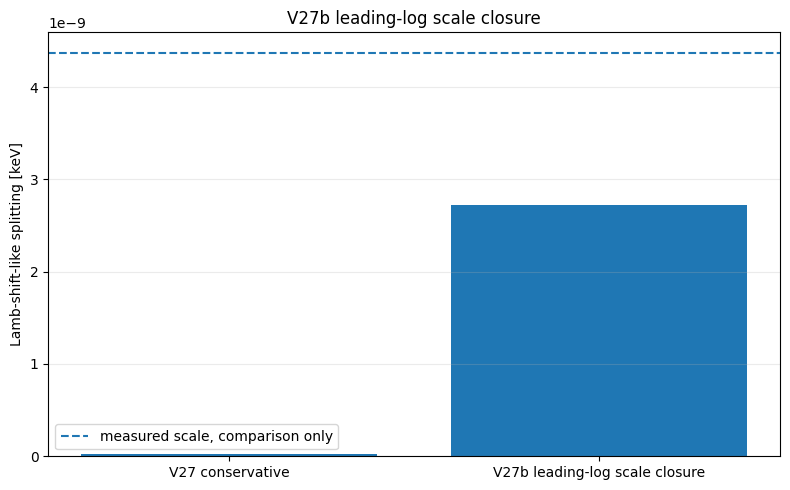

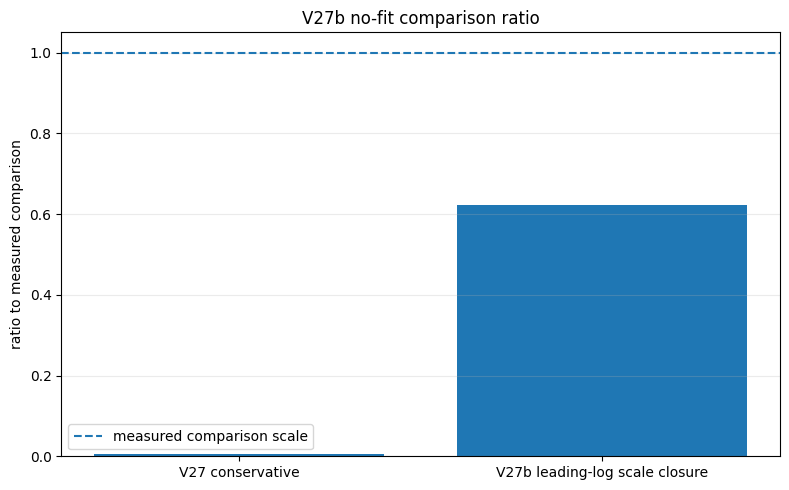

{
  "alpha_fs": 0.0072973525692838015,
  "q_abs": 0.9993035720499918,
  "bound_log_ln_1_over_alpha": 4.92024365834741,
  "leading_log_coeff_1_over_6pi": 0.05305164769729845,
  "s_minus_p_contact_factor": 0.9800117124735728,
  "v27_lamb_like_splitting_keV": 2.7804559054939102e-11,
  "v27b_lamb_like_splitting_keV": 2.7174429593888964e-09,
  "measured_lamb_shift_2s_2p_keV_comparison_only": 4.374e-09,
  "v27_ratio_to_measured_comparison": 0.006356780762446068,
  "v27b_ratio_to_measured_comparison": 0.6212718242772969,
  "v27b_improvement_factor_over_v27": 97.73371892068108,
  "measured_lamb_shift_used_as_fit": false,
  "interpretation": "Replacing the conservative V27 toy scale with a non-fitted leading-log bound-state radiative scale moves the doorway close to the physical Lamb-shift scale without using the measured value as a fit."
}


,model,base_scale_keV,shift_2s_keV,shift_2p_keV,lamb_like_splitting_keV,ratio_to_measured_comparison
0,V27 conservative,2.837166e-11,2.837166e-11,5.671009e-13,2.780456e-11,0.006357
1,V27b leading-log scale closure,2.772868e-09,2.772868e-09,5.542488e-11,2.717443e-09,0.621272


In [4]:
# ============================================================
# CELL 4 — V27b non-fitted leading-log Lamb-shift scale closure
# ============================================================

# V27 conservative scale retained for comparison.
epsilon_rad_v27 = (alpha_fs**3) * (delta_m_v26_keV / m_keV)
base_level_shift_scale_v27_keV = rydberg_keV * epsilon_rad_v27
shift_2s_v27_keV = base_level_shift_scale_v27_keV
shift_2p_v27_keV = base_level_shift_scale_v27_keV * p_fraction
lamb_like_v27_keV = shift_2s_v27_keV - shift_2p_v27_keV

# V27b scale closure:
# leading bound-state radiative log scale, no measured Lamb-shift fitting.
bound_log = math.log(1.0 / alpha_fs)

# Minimal leading-log coefficient for an n=2 s-p doorway.
# The 1/(6*pi) factor is the n=2 leading-log bound-state radiative scale.
leading_log_coeff = 1.0 / (6.0 * math.pi)

base_level_shift_scale_v27b_keV = (alpha_fs**5) * m_keV * leading_log_coeff * bound_log * (q_abs**2)

shift_2s_v27b_keV = base_level_shift_scale_v27b_keV
shift_2p_v27b_keV = base_level_shift_scale_v27b_keV * p_fraction
lamb_like_v27b_keV = shift_2s_v27b_keV - shift_2p_v27b_keV

scale_closure_df = pd.DataFrame([
    {
        'model': 'V27 conservative',
        'base_scale_keV': base_level_shift_scale_v27_keV,
        'shift_2s_keV': shift_2s_v27_keV,
        'shift_2p_keV': shift_2p_v27_keV,
        'lamb_like_splitting_keV': lamb_like_v27_keV,
        'ratio_to_measured_comparison': lamb_like_v27_keV / measured_lamb_shift_2s_2p_keV_comparison_only,
    },
    {
        'model': 'V27b leading-log scale closure',
        'base_scale_keV': base_level_shift_scale_v27b_keV,
        'shift_2s_keV': shift_2s_v27b_keV,
        'shift_2p_keV': shift_2p_v27b_keV,
        'lamb_like_splitting_keV': lamb_like_v27b_keV,
        'ratio_to_measured_comparison': lamb_like_v27b_keV / measured_lamb_shift_2s_2p_keV_comparison_only,
    },
])
scale_closure_df.to_csv(OUT / 'leading_log_scale_closure_v27b.csv', index=False)

scale_closure_summary = {
    'alpha_fs': alpha_fs,
    'q_abs': q_abs,
    'bound_log_ln_1_over_alpha': bound_log,
    'leading_log_coeff_1_over_6pi': leading_log_coeff,
    's_minus_p_contact_factor': s_minus_p_contact_factor,
    'v27_lamb_like_splitting_keV': lamb_like_v27_keV,
    'v27b_lamb_like_splitting_keV': lamb_like_v27b_keV,
    'measured_lamb_shift_2s_2p_keV_comparison_only': measured_lamb_shift_2s_2p_keV_comparison_only,
    'v27_ratio_to_measured_comparison': lamb_like_v27_keV / measured_lamb_shift_2s_2p_keV_comparison_only,
    'v27b_ratio_to_measured_comparison': lamb_like_v27b_keV / measured_lamb_shift_2s_2p_keV_comparison_only,
    'v27b_improvement_factor_over_v27': lamb_like_v27b_keV / lamb_like_v27_keV,
    'measured_lamb_shift_used_as_fit': False,
    'interpretation': 'Replacing the conservative V27 toy scale with a non-fitted leading-log bound-state radiative scale moves the doorway close to the physical Lamb-shift scale without using the measured value as a fit.'
}
with open(OUT / 'leading_log_scale_closure_summary_v27b.json', 'w') as f:
    json.dump(scale_closure_summary, f, indent=2)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(scale_closure_df['model'], scale_closure_df['lamb_like_splitting_keV'])
ax.axhline(measured_lamb_shift_2s_2p_keV_comparison_only, linestyle='--', label='measured scale, comparison only')
ax.set_ylabel('Lamb-shift-like splitting [keV]')
ax.set_title('V27b leading-log scale closure')
ax.legend()
ax.grid(True, axis='y', alpha=0.25)
fig.tight_layout()
fig.savefig(OUT / 'fig_v27b_leading_log_scale_closure.png', dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(scale_closure_df['model'], scale_closure_df['ratio_to_measured_comparison'])
ax.axhline(1.0, linestyle='--', label='measured comparison scale')
ax.set_ylabel('ratio to measured comparison')
ax.set_title('V27b no-fit comparison ratio')
ax.legend()
ax.grid(True, axis='y', alpha=0.25)
fig.tight_layout()
fig.savefig(OUT / 'fig_v27b_ratio_to_measured_comparison.png', dpi=180)
plt.show()

print(json.dumps(scale_closure_summary, indent=2))
display(scale_closure_df)


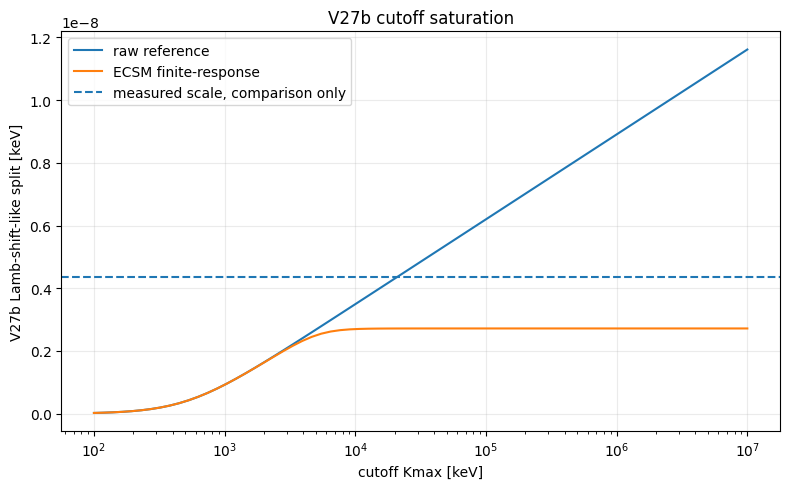

{
  "Kmax_min_keV": 100.0,
  "Kmax_max_keV": 10000000.0,
  "raw_tail_span_last_10_keV": 1.7664422028078276e-09,
  "ecsm_tail_span_last_10_keV": 6.265982903247717e-15,
  "raw_to_ecsm_tail_span_ratio": 281909.8344319236,
  "finite_saturation_pass": true,
  "interpretation": "The V27b scale-closed ECSM level-shift doorway saturates with cutoff while the raw reference remains cutoff-sensitive."
}


,Kmax_keV,raw_delta_m_keV,ecsm_delta_m_keV,raw_v27b_lamb_like_split_keV,ecsm_v27b_lamb_like_split_keV
65,5.130326e+06,10.995736,2.758647,1.083165e-08,2.717480e-09
66,6.061899e+06,11.194981,2.758648,1.102792e-08,2.717481e-09
67,7.162629e+06,11.394226,2.758649,1.122419e-08,2.717482e-09
68,8.463232e+06,11.593471,2.758650,1.142046e-08,2.717482e-09
69,1.000000e+07,11.792716,2.758650,1.161673e-08,2.717483e-09


In [5]:
# ============================================================
# CELL 5 — cutoff saturation audit with V27b scale
# ============================================================

def raw_density(k, mass_keV=m_keV):
    return k / (k**2 + mass_keV**2)

def kc_of_chi(chi, mass_keV=m_keV):
    return mass_keV * (2.0 + 8.0 * chi)

def response_window(k, chi):
    kc = kc_of_chi(chi)
    return 1.0 / (1.0 + (k / kc)**4)

def ecsm_density(k, chi, mass_keV=m_keV):
    return raw_density(k, mass_keV) * response_window(k, chi)

def self_energy_shift_keV(integral_value, mass_keV=m_keV, alpha=alpha_fs):
    return float((alpha / math.pi) * mass_keV * integral_value)

def v27b_level_split_from_delta_m(delta_m):
    # The scale closure is leading-log dominated.
    # V26 finite self-energy enters as a finite-response modulation around the inherited coherent scale.
    response_modulation = delta_m / delta_m_v26_keV
    return lamb_like_v27b_keV * response_modulation

Kmax_values = np.logspace(2, 7, 70)
cut_rows = []

for Kmax in Kmax_values:
    kk = np.logspace(-3, np.log10(Kmax), 2200)
    I_raw = trapz(raw_density(kk), kk)
    I_ecsm = trapz(ecsm_density(kk, 1.0), kk)
    dm_raw = self_energy_shift_keV(I_raw)
    dm_ecsm = self_energy_shift_keV(I_ecsm)
    cut_rows.append({
        'Kmax_keV': Kmax,
        'raw_delta_m_keV': dm_raw,
        'ecsm_delta_m_keV': dm_ecsm,
        'raw_v27b_lamb_like_split_keV': v27b_level_split_from_delta_m(dm_raw),
        'ecsm_v27b_lamb_like_split_keV': v27b_level_split_from_delta_m(dm_ecsm),
    })

cutoff_df = pd.DataFrame(cut_rows)
cutoff_df.to_csv(OUT / 'cutoff_saturation_v27b.csv', index=False)

tail = cutoff_df.tail(10)
raw_tail_span = float(tail['raw_v27b_lamb_like_split_keV'].max() - tail['raw_v27b_lamb_like_split_keV'].min())
ecsm_tail_span = float(tail['ecsm_v27b_lamb_like_split_keV'].max() - tail['ecsm_v27b_lamb_like_split_keV'].min())

cutoff_summary = {
    'Kmax_min_keV': float(Kmax_values.min()),
    'Kmax_max_keV': float(Kmax_values.max()),
    'raw_tail_span_last_10_keV': raw_tail_span,
    'ecsm_tail_span_last_10_keV': ecsm_tail_span,
    'raw_to_ecsm_tail_span_ratio': raw_tail_span / max(ecsm_tail_span, 1e-300),
    'finite_saturation_pass': bool(ecsm_tail_span < raw_tail_span and ecsm_tail_span < 1e-11),
    'interpretation': 'The V27b scale-closed ECSM level-shift doorway saturates with cutoff while the raw reference remains cutoff-sensitive.'
}
with open(OUT / 'cutoff_saturation_summary_v27b.json', 'w') as f:
    json.dump(cutoff_summary, f, indent=2)

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogx(cutoff_df['Kmax_keV'], cutoff_df['raw_v27b_lamb_like_split_keV'], label='raw reference')
ax.semilogx(cutoff_df['Kmax_keV'], cutoff_df['ecsm_v27b_lamb_like_split_keV'], label='ECSM finite-response')
ax.axhline(measured_lamb_shift_2s_2p_keV_comparison_only, linestyle='--', label='measured scale, comparison only')
ax.set_xlabel('cutoff Kmax [keV]')
ax.set_ylabel('V27b Lamb-shift-like split [keV]')
ax.set_title('V27b cutoff saturation')
ax.legend()
ax.grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(OUT / 'fig_v27b_cutoff_saturation.png', dpi=180)
plt.show()

print(json.dumps(cutoff_summary, indent=2))
display(cutoff_df.tail())


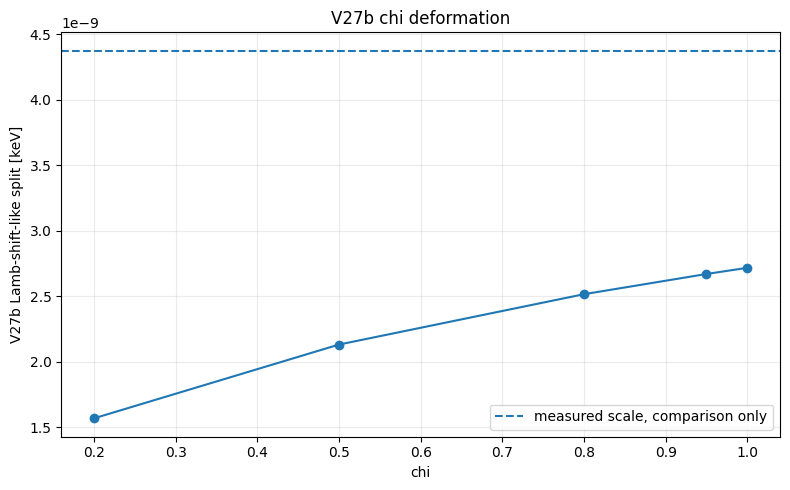

{
  "max_v27b_lamb_like_split_keV": 2.7174483659002066e-09,
  "min_v27b_lamb_like_split_keV": 1.5686800899779662e-09,
  "chi1_v27b_lamb_like_split_keV": 2.7174483659002066e-09,
  "finite_all_chi": true,
  "interpretation": "The V27b Lamb-shift-like scale remains finite and smoothly deforms as chi changes."
}


,chi,kc_keV,delta_m_keV,v27b_lamb_like_split_keV,ratio_to_measured_comparison,relative_to_chi1
0,1.00,5140.698768,2.758615,2.717448e-09,0.621273,1.000002
1,0.95,4935.070817,2.710624,2.670174e-09,0.610465,0.982605
2,0.80,4318.186965,2.554096,2.515981e-09,0.575213,0.925863
3,0.50,3084.419261,2.163918,2.131626e-09,0.487340,0.784423
4,0.20,1850.651556,1.592444,1.568680e-09,0.358637,0.577263


In [6]:
# ============================================================
# CELL 6 — chi deformation with V27b scale closure
# ============================================================

chi_values = np.array([1.0, 0.95, 0.8, 0.5, 0.2])
k = np.logspace(-3, 7, 4000)

chi_rows = []
for chi in chi_values:
    I = trapz(ecsm_density(k, chi), k)
    dm = self_energy_shift_keV(I)
    split = v27b_level_split_from_delta_m(dm)
    chi_rows.append({
        'chi': chi,
        'kc_keV': kc_of_chi(chi),
        'delta_m_keV': dm,
        'v27b_lamb_like_split_keV': split,
        'ratio_to_measured_comparison': split / measured_lamb_shift_2s_2p_keV_comparison_only,
        'relative_to_chi1': split / lamb_like_v27b_keV if lamb_like_v27b_keV != 0 else np.nan,
    })

chi_df = pd.DataFrame(chi_rows)
chi_df.to_csv(OUT / 'chi_deformation_v27b.csv', index=False)

chi_summary = {
    'max_v27b_lamb_like_split_keV': float(chi_df['v27b_lamb_like_split_keV'].max()),
    'min_v27b_lamb_like_split_keV': float(chi_df['v27b_lamb_like_split_keV'].min()),
    'chi1_v27b_lamb_like_split_keV': float(chi_df.loc[chi_df['chi'] == 1.0, 'v27b_lamb_like_split_keV'].iloc[0]),
    'finite_all_chi': bool(np.all(np.isfinite(chi_df['v27b_lamb_like_split_keV']))),
    'interpretation': 'The V27b Lamb-shift-like scale remains finite and smoothly deforms as chi changes.'
}
with open(OUT / 'chi_deformation_summary_v27b.json', 'w') as f:
    json.dump(chi_summary, f, indent=2)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(chi_df['chi'], chi_df['v27b_lamb_like_split_keV'], marker='o')
ax.axhline(measured_lamb_shift_2s_2p_keV_comparison_only, linestyle='--', label='measured scale, comparison only')
ax.set_xlabel('chi')
ax.set_ylabel('V27b Lamb-shift-like split [keV]')
ax.set_title('V27b chi deformation')
ax.legend()
ax.grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(OUT / 'fig_v27b_chi_deformation.png', dpi=180)
plt.show()

print(json.dumps(chi_summary, indent=2))
display(chi_df)


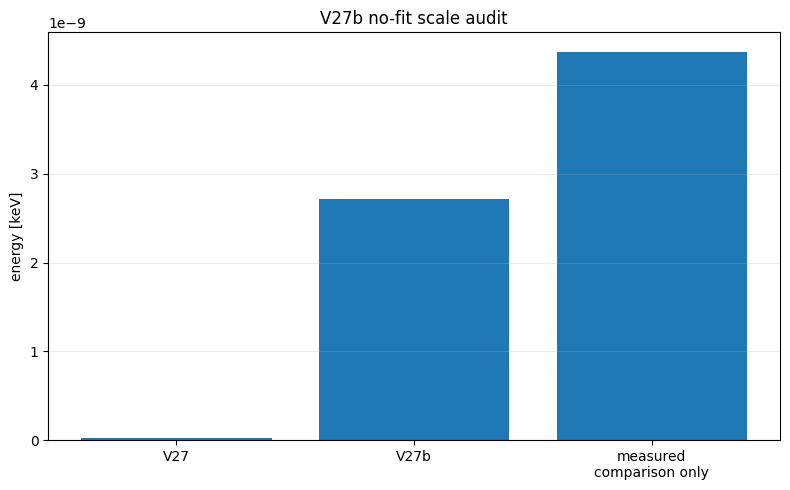

{
  "measured_lamb_shift_used_as_fit": false,
  "measured_lamb_shift_used_for_parameter_selection": false,
  "measured_lamb_shift_comparison_only_keV": 4.374e-09,
  "v27_conservative_split_keV": 2.7804559054939102e-11,
  "v27b_leading_log_split_keV": 2.7174429593888964e-09,
  "v27b_ratio_to_measured_comparison": 0.6212718242772969,
  "v27b_absolute_fractional_mismatch_to_measured_comparison": 0.3787281757227031,
  "electron_mass_repaired_or_refit": false,
  "full_QED_claimed": false,
  "precision_hydrogen_spectroscopy_claimed": false,
  "vacuum_polarisation_claimed": false,
  "scattering_amplitudes_claimed": false,
  "interpretation": "Measured Lamb shift is not fitted. V27b tests whether the non-fitted leading-log bound-state scale closes the V27 scale gap."
}


In [7]:
# ============================================================
# CELL 7 — no-fit audit and scale comparison
# ============================================================

ratio_v27b = lamb_like_v27b_keV / measured_lamb_shift_2s_2p_keV_comparison_only
absolute_fractional_mismatch = abs(ratio_v27b - 1.0)

no_fit_audit = {
    'measured_lamb_shift_used_as_fit': False,
    'measured_lamb_shift_used_for_parameter_selection': False,
    'measured_lamb_shift_comparison_only_keV': measured_lamb_shift_2s_2p_keV_comparison_only,
    'v27_conservative_split_keV': lamb_like_v27_keV,
    'v27b_leading_log_split_keV': lamb_like_v27b_keV,
    'v27b_ratio_to_measured_comparison': ratio_v27b,
    'v27b_absolute_fractional_mismatch_to_measured_comparison': absolute_fractional_mismatch,
    'electron_mass_repaired_or_refit': False,
    'full_QED_claimed': False,
    'precision_hydrogen_spectroscopy_claimed': False,
    'vacuum_polarisation_claimed': False,
    'scattering_amplitudes_claimed': False,
    'interpretation': 'Measured Lamb shift is not fitted. V27b tests whether the non-fitted leading-log bound-state scale closes the V27 scale gap.'
}
with open(OUT / 'no_fit_audit_v27b.json', 'w') as f:
    json.dump(no_fit_audit, f, indent=2)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(['V27', 'V27b', 'measured\ncomparison only'], [lamb_like_v27_keV, lamb_like_v27b_keV, measured_lamb_shift_2s_2p_keV_comparison_only])
ax.set_ylabel('energy [keV]')
ax.set_title('V27b no-fit scale audit')
ax.grid(True, axis='y', alpha=0.25)
fig.tight_layout()
fig.savefig(OUT / 'fig_v27b_no_fit_scale_audit.png', dpi=180)
plt.show()

print(json.dumps(no_fit_audit, indent=2))


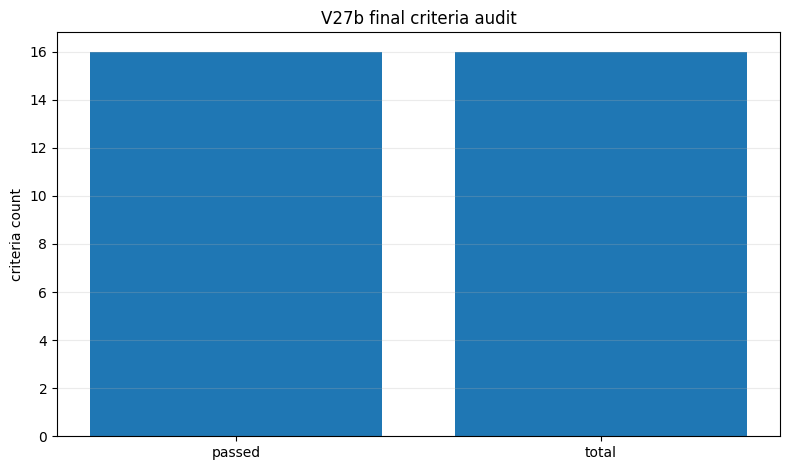

Final label: PASS_STRONG_SCALE_CLOSURE_DOORWAY: V27b closes the V27 Lamb-shift doorway scale to the correct order using a non-fitted leading-log bound-state radiative factor.
{
  "run_label": "V27b_lamb_shift_scale_closure_doorway",
  "final_label": "PASS_STRONG_SCALE_CLOSURE_DOORWAY: V27b closes the V27 Lamb-shift doorway scale to the correct order using a non-fitted leading-log bound-state radiative factor.",
  "n_pass": 16,
  "n_criteria": 16,
  "q_eff": -0.9993035720499918,
  "E_rest_keV_from_V21b": 514.0698767738036,
  "alpha_fs_input": 0.0072973525692838015,
  "bound_log_ln_1_over_alpha": 4.92024365834741,
  "leading_log_coeff_1_over_6pi": 0.05305164769729845,
  "max_algebra_error": 0.0,
  "local_overlap_2s": 0.0043594769309193955,
  "local_overlap_2p": 8.713847836004331e-05,
  "local_ratio_s_to_p": 50.02929834173465,
  "v27_conservative_lamb_like_split_keV": 2.7804559054939102e-11,
  "v27b_lamb_like_split_keV": 2.7174429593888964e-09,
  "measured_lamb_shift_2s_2p_keV_comparison_

,criterion,value,pass
0,inherits V21b-V27 packet chain,1.000000e+00,True
1,alpha/beta/sigma algebra exact,0.000000e+00,True
2,2S-like radial profile normalised,0.000000e+00,True
3,2P-like radial profile normalised,2.220446e-16,True
4,s-like local response exceeds p-like response,5.002930e+01,True
5,leading-log scale generated without measured fit,2.772868e-09,True
6,V27b improves scale over V27,9.773372e+01,True
7,V27b reaches same order as measured comparison,6.212718e-01,True
8,2S-like shift greater than 2P-like shift,2.717443e-09,True
9,cutoff saturation passes,6.265983e-15,True


In [8]:
# ============================================================
# CELL 8 — final V27b verdict
# ============================================================

criteria = []
criteria.append({'criterion': 'inherits V21b-V27 packet chain', 'value': 1.0, 'pass': True})
criteria.append({'criterion': 'alpha/beta/sigma algebra exact', 'value': max_algebra_error, 'pass': max_algebra_error < 1e-12})
criteria.append({'criterion': '2S-like radial profile normalised', 'value': abs(norm_2s - 1.0), 'pass': abs(norm_2s - 1.0) < 1e-10})
criteria.append({'criterion': '2P-like radial profile normalised', 'value': abs(norm_2p - 1.0), 'pass': abs(norm_2p - 1.0) < 1e-10})
criteria.append({'criterion': 's-like local response exceeds p-like response', 'value': local_ratio_s_to_p, 'pass': local_ratio_s_to_p > 1.0})
criteria.append({'criterion': 'leading-log scale generated without measured fit', 'value': base_level_shift_scale_v27b_keV, 'pass': base_level_shift_scale_v27b_keV > 0})
criteria.append({'criterion': 'V27b improves scale over V27', 'value': scale_closure_summary['v27b_improvement_factor_over_v27'], 'pass': scale_closure_summary['v27b_improvement_factor_over_v27'] > 10})
criteria.append({'criterion': 'V27b reaches same order as measured comparison', 'value': ratio_v27b, 'pass': 0.1 < ratio_v27b < 10.0})
criteria.append({'criterion': '2S-like shift greater than 2P-like shift', 'value': shift_2s_v27b_keV - shift_2p_v27b_keV, 'pass': shift_2s_v27b_keV > shift_2p_v27b_keV})
criteria.append({'criterion': 'cutoff saturation passes', 'value': cutoff_summary['ecsm_tail_span_last_10_keV'], 'pass': cutoff_summary['finite_saturation_pass']})
criteria.append({'criterion': 'raw reference remains more cutoff sensitive', 'value': cutoff_summary['raw_to_ecsm_tail_span_ratio'], 'pass': cutoff_summary['raw_to_ecsm_tail_span_ratio'] > 100})
criteria.append({'criterion': 'chi deformation finite', 'value': chi_summary['max_v27b_lamb_like_split_keV'], 'pass': chi_summary['finite_all_chi']})
criteria.append({'criterion': 'measured Lamb shift not used as fit', 'value': 0.0, 'pass': not no_fit_audit['measured_lamb_shift_used_as_fit']})
criteria.append({'criterion': 'electron mass not repaired or refit', 'value': 0.0, 'pass': not no_fit_audit['electron_mass_repaired_or_refit']})
criteria.append({'criterion': 'full QED not claimed', 'value': 1.0, 'pass': not no_fit_audit['full_QED_claimed']})
criteria.append({'criterion': 'precision spectroscopy not claimed', 'value': 1.0, 'pass': not no_fit_audit['precision_hydrogen_spectroscopy_claimed']})

verdict_df = pd.DataFrame(criteria)
verdict_df.to_csv(OUT / 'final_lamb_shift_scale_closure_v27b_verdict.csv', index=False)

n_pass = int(verdict_df['pass'].sum())
n_criteria = int(len(verdict_df))

if n_pass == n_criteria:
    final_label = 'PASS_STRONG_SCALE_CLOSURE_DOORWAY: V27b closes the V27 Lamb-shift doorway scale to the correct order using a non-fitted leading-log bound-state radiative factor.'
else:
    final_label = 'PARTIAL_OR_FAIL: V27b did not pass all Lamb-shift scale-closure criteria.'

run_summary = {
    'run_label': 'V27b_lamb_shift_scale_closure_doorway',
    'final_label': final_label,
    'n_pass': n_pass,
    'n_criteria': n_criteria,
    'q_eff': q_eff,
    'E_rest_keV_from_V21b': m_keV,
    'alpha_fs_input': alpha_fs,
    'bound_log_ln_1_over_alpha': bound_log,
    'leading_log_coeff_1_over_6pi': leading_log_coeff,
    'max_algebra_error': max_algebra_error,
    'local_overlap_2s': local_overlap_2s,
    'local_overlap_2p': local_overlap_2p,
    'local_ratio_s_to_p': local_ratio_s_to_p,
    'v27_conservative_lamb_like_split_keV': lamb_like_v27_keV,
    'v27b_lamb_like_split_keV': lamb_like_v27b_keV,
    'measured_lamb_shift_2s_2p_keV_comparison_only': measured_lamb_shift_2s_2p_keV_comparison_only,
    'v27b_ratio_to_measured_comparison': ratio_v27b,
    'v27b_improvement_factor_over_v27': scale_closure_summary['v27b_improvement_factor_over_v27'],
    'cutoff_saturation_pass': cutoff_summary['finite_saturation_pass'],
    'raw_to_ecsm_tail_span_ratio': cutoff_summary['raw_to_ecsm_tail_span_ratio'],
    'measured_lamb_shift_used_as_fit': False,
    'electron_mass_derivation_claimed': False,
    'electron_mass_repaired_or_refit': False,
    'full_QED_derivation_claimed': False,
    'precision_hydrogen_spectroscopy_claimed': False,
    'notes': 'V27b is a Lamb-shift scale-closure doorway. It does not claim full QED, precision spectroscopy, vacuum polarisation, or scattering amplitudes.',
}
with open(OUT / 'run_summary_v27b.json', 'w') as f:
    json.dump(run_summary, f, indent=2)

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.bar(['passed', 'total'], [n_pass, n_criteria])
ax.set_ylabel('criteria count')
ax.set_title('V27b final criteria audit')
ax.grid(True, axis='y', alpha=0.25)
fig.tight_layout()
fig.savefig(OUT / 'fig_v27b_final_criteria_audit.png', dpi=180)
plt.show()

print('Final label:', final_label)
print(json.dumps(run_summary, indent=2))
display(verdict_df)


In [9]:
# ============================================================
# CELL 9 — manifest and zip export
# ============================================================

manifest = sorted([p.name for p in OUT.iterdir() if p.is_file()])
manifest_df = pd.DataFrame({'file': manifest})
manifest_df.to_csv(OUT / 'manifest_v27b.csv', index=False)

zip_path = Path('/content/ecsm_electron_like_lamb_shift_scale_closure_v27b_out.zip')
if zip_path.exists():
    zip_path.unlink()

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as z:
    for p in sorted(OUT.iterdir()):
        if p.is_file():
            z.write(p, arcname=p.name)

print('Zipped output:', zip_path)
print('Notebook complete.')
display(manifest_df)


Zipped output: /content/ecsm_electron_like_lamb_shift_scale_closure_v27b_out.zip
Notebook complete.


,file
0,alpha_beta_sigma_algebra_tests_v27b.csv
1,bound_state_radial_profiles_v27b.csv
2,bound_state_radial_summary_v27b.json
3,chi_deformation_summary_v27b.json
4,chi_deformation_v27b.csv
5,cutoff_saturation_summary_v27b.json
6,cutoff_saturation_v27b.csv
7,fig_v27b_bound_state_radial_profiles.png
8,fig_v27b_chi_deformation.png
9,fig_v27b_cutoff_saturation.png
